# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

In [4]:
from load_ensembles import *
from load_gridcell_areas import *
from plotting_settings import *

# Load data

In [5]:
path_in='/glade/work/czarakas/coupled_PPE/data/data_for_figures/'

### Land Only

In [6]:
ds_Ts_land = xr.open_dataset(path_in+'annual_means/delta_TSKIN_Annual_mean_coupled.nc')['TSKIN']
pvals_Ts_land=xr.open_dataset(path_in+'annual_means/pval_TSKIN_Annual_mean_coupled.nc')['pval']

ds_ref_land=xr.open_dataset(path_in+'annual_means/ref_TSKIN_Annual_mean_coupled.nc')['TSKIN']

### Land and Ocean

In [7]:
ds_Ts_global = xr.open_dataset(path_in+'annual_means/delta_TS_Annual_mean_coupled.nc')['TS']
pvals_Ts_global=xr.open_dataset(path_in+'annual_means/pval_TS_Annual_mean_coupled.nc')['pval']

ds_ref_global=xr.open_dataset(path_in+'annual_means/ref_TS_Annual_mean_coupled.nc')['TS']

In [8]:
ds_P = xr.open_dataset(path_in+'annual_means/delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']
pvals_P=xr.open_dataset(path_in+'annual_means/pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['pval']

ds_ref=xr.open_dataset(path_in+'annual_means/ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')['calculated_PREC_FROM_ATM']

# Process data

### Reindex weights as needed

In [9]:
landweights_atm=landweights2.reindex_like(ds_ref_global, method='nearest',tolerance=0.05)
weight_factor_atm=weight_factor_atm.reindex_like(ds_ref_global, method='nearest',tolerance=0.05)

landweights_lnd=landweights2.reindex_like(ds_ref_land, method='nearest',tolerance=0.05)
weight_factor_lnd=weight_factor_atm.reindex_like(ds_ref_land, method='nearest',tolerance=0.05)

# Make figure

In [10]:
global_Ts=(ds_Ts_global*weight_factor_atm).mean(dim=['lat','lon'])
land_Ts=(ds_Ts_land*landweights_lnd).sum(dim=['lat','lon'])

In [11]:
zeta_ind=(crosswalk.param=='zetamaxstable').values

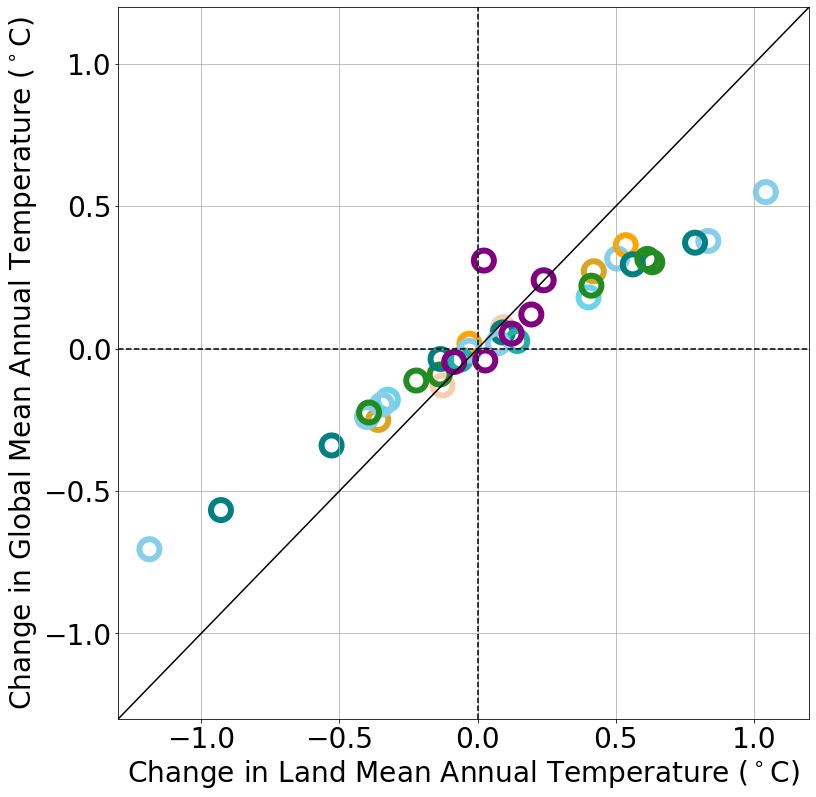

In [12]:
minval=-1.3
maxval=1.2
plt.rcParams.update({'font.size': 28})

plt.figure(figsize=(12,12))

#plt.scatter(land_Ts[zeta_ind], global_Ts[zeta_ind], s=400, 
#            c=np.array(colors)[zeta_ind],
#            linewidth=6)
plt.plot([minval,maxval],[minval,maxval],'-k')
plt.scatter(land_Ts, global_Ts, s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)
plt.grid()
plt.axhline(y=0,linestyle='--',color='k')
plt.axvline(x=0,linestyle='--',color='k')
plt.xlabel('Change in Land Mean Annual Temperature ($^\circ$C)')
plt.ylabel('Change in Global Mean Annual Temperature ($^\circ$C)')
plt.xlim([minval,maxval])
plt.ylim([minval,maxval])
plt.tight_layout()
plt.savefig('../Figures/Figure_S3.pdf')